# Learning Log: Classifying Newsgroup Posts with KNN & Naive Bayes

I'm working through the text-classification chapter of my ML coursework, and wanted a place to
replay the ideas in my own words and with my own experiments instead of just leaving them in a
graded notebook. This entry is about turning raw text into numeric features (bag-of-words,
TF-IDF) and then comparing a distance-based classifier (KNN) against two flavors of Naive Bayes
on real newsgroup posts.

**Dataset:** [20 Newsgroups](http://qwone.com/~jason/20Newsgroups/) — ~20,000 posts split across
20 discussion boards. I'm only using 4 categories so training stays fast on my laptop.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, neighbors, naive_bayes, model_selection
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline

np.random.seed(42)


## 1. Pulling in the data

I picked four categories that don't overlap much in vocabulary, so it's a reasonably fair test
for bag-of-words style features: cars, medicine, Mac hardware, and Middle East politics.


In [2]:
categories = ['rec.autos', 'sci.med', 'comp.sys.mac.hardware', 'talk.politics.mideast']

train = datasets.fetch_20newsgroups(
    subset='train', categories=categories,
    remove=('headers', 'footers', 'quotes'), data_home='./.cache',
)
test = datasets.fetch_20newsgroups(
    subset='test', categories=categories,
    remove=('headers', 'footers', 'quotes'), data_home='./.cache',
)

print(f"train size: {len(train.data)}, test size: {len(test.data)}")
for i, name in enumerate(train.target_names):
    print(f"  {name:25s}: {np.sum(train.target == i)} train docs")


train size: 2330, test size: 1553
  comp.sys.mac.hardware    : 578 train docs
  rec.autos                : 594 train docs
  sci.med                  : 594 train docs
  talk.politics.mideast    : 564 train docs


## 2. From words to numbers

A classifier can't read raw text, so the first step is always turning each document into a
vector. The two representations I want to compare:

- **Bag-of-words (counts):** how many times each vocabulary word shows up in a document.
- **TF-IDF:** counts re-weighted so common words across the whole corpus (like "the", "just")
  matter less, and words that are distinctive to a document matter more.

Quick sanity check on a toy corpus before touching the real data:


In [3]:
toy_corpus = [
    "the engine needs an oil change",
    "the doctor changed my medication",
    "my mac needs more memory",
]
vec = CountVectorizer()
X_toy = vec.fit_transform(toy_corpus)
print(vec.get_feature_names_out())
print(X_toy.toarray())


['an' 'change' 'changed' 'doctor' 'engine' 'mac' 'medication' 'memory'
 'more' 'my' 'needs' 'oil' 'the']
[[1 1 0 0 1 0 0 0 0 0 1 1 1]
 [0 0 1 1 0 0 1 0 0 1 0 0 1]
 [0 0 0 0 0 1 0 1 1 1 1 0 0]]


## 3. KNN baseline

KNN classifies a document by looking at its closest neighbors in feature space, so it's a good
"does the representation even make sense" sanity check before trying anything fancier. I swept
over a handful of neighbor counts with 5-fold cross-validation.


In [4]:
vectorizer = CountVectorizer(stop_words='english', max_features=3000)
X_train = vectorizer.fit_transform(train.data)
X_test = vectorizer.transform(test.data)
y_train, y_test = train.target, test.target

knn_grid = {'n_neighbors': [1, 3, 5, 7, 9, 11]}
clf_knn = model_selection.GridSearchCV(
    neighbors.KNeighborsClassifier(), param_grid=knn_grid, cv=5, n_jobs=-1,
)
clf_knn.fit(X_train, y_train)

print("best k:", clf_knn.best_params_)
print("train accuracy:", clf_knn.score(X_train, y_train))
print("test accuracy: ", clf_knn.score(X_test, y_test))


best k: {'n_neighbors': 1}


train accuracy: 0.9695278969957082
test accuracy:  0.46297488731487446


Not great — KNN struggles here because bag-of-words vectors are high-dimensional and sparse,
so "distance" between documents stops being a very meaningful notion (the curse of
dimensionality). That's the motivation for trying a model built specifically for this kind of
data next.


## 4. Bernoulli Naive Bayes

Bernoulli NB only cares whether a word is present or absent in a document, not how many times it
shows up. I ran a grid search over the vocabulary size and the smoothing parameter `alpha`
together, using a `Pipeline` so both steps get cross-validated jointly.


In [5]:
pipeline_bnb = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english')),
    ('classifier', naive_bayes.BernoulliNB()),
])

param_grid_bnb = {
    'vectorizer__max_features': [1000, 2000, 3000, 5000],
    'classifier__alpha': [0.01, 0.1, 0.5, 1.0],
}

clf_bnb = model_selection.GridSearchCV(pipeline_bnb, param_grid=param_grid_bnb, cv=5, n_jobs=-1)
clf_bnb.fit(train.data, y_train)

print("best params:", clf_bnb.best_params_)
print("test accuracy:", clf_bnb.score(test.data, y_test))


best params: {'classifier__alpha': 0.01, 'vectorizer__max_features': 5000}
test accuracy: 0.7952350289761752


In [6]:
# Which words push the model most strongly towards each category?
best_vec = clf_bnb.best_estimator_.named_steps['vectorizer']
best_bnb = clf_bnb.best_estimator_.named_steps['classifier']
feature_names = np.asarray(best_vec.get_feature_names_out())

for i, name in enumerate(train.target_names):
    top = np.argsort(best_bnb.feature_log_prob_[i])[-8:]
    print(f"\n{name}:")
    for idx in top:
        print(f"    {feature_names[idx]:15s} ({best_bnb.feature_log_prob_[i][idx]:.3f})")



comp.sys.mac.hardware:
    use             (-1.677)
    like            (-1.650)
    just            (-1.650)
    thanks          (-1.606)
    does            (-1.564)
    apple           (-1.547)
    know            (-1.508)
    mac             (-1.356)

rec.autos:
    think           (-1.898)
    good            (-1.792)
    know            (-1.792)
    cars            (-1.659)
    don             (-1.625)
    just            (-1.535)
    like            (-1.460)
    car             (-0.966)

sci.med:
    think           (-1.677)
    time            (-1.668)
    edu             (-1.633)
    just            (-1.616)
    people          (-1.567)
    like            (-1.496)
    know            (-1.417)
    don             (-1.396)

talk.politics.mideast:
    time            (-1.581)
    know            (-1.581)
    don             (-1.573)
    israeli         (-1.515)
    israel          (-1.285)
    just            (-1.279)
    like            (-1.272)
    people          (-0.993)


## 5. Multinomial Naive Bayes + TF-IDF

Multinomial NB models word *counts* rather than presence/absence, so it pairs naturally with
TF-IDF weighting. Same grid-search setup, but now with a TF-IDF step in the pipeline.


In [7]:
pipeline_mnb = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english')),
    ('tfidf', TfidfTransformer()),
    ('classifier', naive_bayes.MultinomialNB()),
])

param_grid_mnb = {
    'vectorizer__max_features': [1000, 2000, 3000, 5000],
    'tfidf__norm': ['l1', 'l2'],
    'classifier__alpha': [0.001, 0.01, 0.1, 0.5, 1.0],
}

clf_mnb = model_selection.GridSearchCV(pipeline_mnb, param_grid=param_grid_mnb, cv=5, n_jobs=-1)
clf_mnb.fit(train.data, y_train)

print("best params:", clf_mnb.best_params_)
print("test accuracy:", clf_mnb.score(test.data, y_test))


best params: {'classifier__alpha': 0.01, 'tfidf__norm': 'l2', 'vectorizer__max_features': 5000}


test accuracy: 0.8937540244687702


**Takeaway so far:** Multinomial NB + TF-IDF beat both KNN and Bernoulli NB by a solid margin.
It makes sense — TF-IDF gives the model frequency information Bernoulli throws away, and Naive
Bayes doesn't fall apart in high dimensions the way KNN's distance metric does.


## 6. How much does the smoothing parameter matter?

`alpha` controls how much probability mass gets shifted towards unseen words. Too low and the
model overfits to the training vocabulary; too high and it stops distinguishing categories at
all. I swept alpha on a log scale, holding vocabulary size fixed, to see the shape of the curve.


best alpha: 0.52983  (test accuracy 0.891)


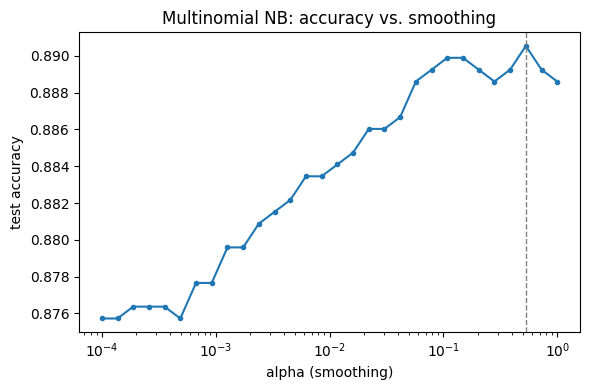

In [8]:
alphas = np.logspace(-4, 0, 30)
alpha_accuracies = []

for a in alphas:
    pipe = Pipeline([
        ('vectorizer', CountVectorizer(stop_words='english', max_features=3000)),
        ('tfidf', TfidfTransformer()),
        ('classifier', naive_bayes.MultinomialNB(alpha=a)),
    ])
    pipe.fit(train.data, y_train)
    alpha_accuracies.append(pipe.score(test.data, y_test))

best_alpha = alphas[int(np.argmax(alpha_accuracies))]
print(f"best alpha: {best_alpha:.5f}  (test accuracy {max(alpha_accuracies):.3f})")

plt.figure(figsize=(6, 4))
plt.semilogx(alphas, alpha_accuracies, marker='o', markersize=3)
plt.axvline(best_alpha, color='gray', linestyle='--', linewidth=1)
plt.xlabel('alpha (smoothing)')
plt.ylabel('test accuracy')
plt.title('Multinomial NB: accuracy vs. smoothing')
plt.tight_layout()
plt.show()


## 7. How much does vocabulary size matter?

Same idea, but sweeping `max_features` with alpha fixed at the best value found above.


best vocab size: 6885  (test accuracy 0.906)


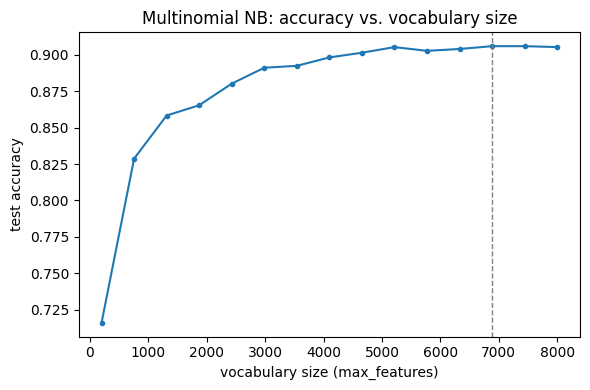

In [9]:
vocab_sizes = np.linspace(200, 8000, 15).astype(int)
vocab_accuracies = []

for v in vocab_sizes:
    pipe = Pipeline([
        ('vectorizer', CountVectorizer(stop_words='english', max_features=v)),
        ('tfidf', TfidfTransformer()),
        ('classifier', naive_bayes.MultinomialNB(alpha=best_alpha)),
    ])
    pipe.fit(train.data, y_train)
    vocab_accuracies.append(pipe.score(test.data, y_test))

best_vocab = vocab_sizes[int(np.argmax(vocab_accuracies))]
print(f"best vocab size: {best_vocab}  (test accuracy {max(vocab_accuracies):.3f})")

plt.figure(figsize=(6, 4))
plt.plot(vocab_sizes, vocab_accuracies, marker='o', markersize=3)
plt.axvline(best_vocab, color='gray', linestyle='--', linewidth=1)
plt.xlabel('vocabulary size (max_features)')
plt.ylabel('test accuracy')
plt.title('Multinomial NB: accuracy vs. vocabulary size')
plt.tight_layout()
plt.show()


## What I took away from this

- **Representation matters more than the classifier, up to a point.** Swapping counts for TF-IDF
  helped more than tuning any single hyperparameter.
- **KNN is a bad default for text.** High-dimensional sparse vectors make "nearest neighbor" a
  much weaker signal than it is for, say, tabular or image data.
- **Smoothing has a sweet spot, not a monotonic effect.** Accuracy rises then falls as alpha
  grows — too little smoothing overfits rare words, too much washes out the signal entirely.
- **Bigger vocabulary isn't always better.** Accuracy plateaus (and can even dip slightly) past a
  certain vocabulary size, since the extra words are mostly rare/noisy ones.

Next thing I want to try: swap in `TfidfVectorizer` directly and see if character n-grams help
at all with misspellings/slang that show up a lot in these posts.
